In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


In [2]:
import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
params = dp.loadDefaultParams(0)
#


In [3]:

# for CFC
from statistical_testing import get_p_values
from xfreq import (
    XFreqEvaluateSignal,
    kullback_leibler_modulation_index,
    mean_vector_length,
    mutual_information,
    phase_locking_value,
)
from neurolib.utils.signal import Signal, RatesSignal 
from utils import dummy_detect_down_states, get_amplitude, get_dummy_so_phase, get_phase
import pandas as pd 
import xarray as xr 
from itertools import tee
# for circ
from scipy.stats import circmean, circstd
from spindle_detection import down_state_to_spindle_pow_max_peak
# for TF
from yasa import get_centered_indices, stft_power
import matplotlib as mpl
import matplotlib.pyplot as plt

SW = {"low_freq": None, "high_freq": 3.0}
SP_FAST = {"low_freq": 12.0, "high_freq": 16.0}
SP_SLOW = {"low_freq": 8.0, "high_freq": 12.0}
SP_FULL = {"low_freq": 8.0, "high_freq": 16.0}

def so_phase_while_spindle(so_phase, spindle_amp, down_state_centers, **kwargs):
    """
    Compute SO phase on spindle maximum between down states.

    :param so_phase: phase of the SO
    :type so_phase: np.ndarray
    :param spindle_amp: spindle amplitude
    :type spindle_amp: np.ndarray
    :param down_state_centers: indices of down state centers
    :type down_state_centers: np.ndarray
    :return: SO phases on maximum spindle amplitude
    :rtype: np.ndarray
    """
    SOphases = []

    def pairwise(iterable):
        a, b = tee(iterable)
        next(b, None)
        return zip(a, b)

    spindle_amp_threshold = kwargs.get("sp_amp_thresh", 0.0) #5.0)
    for start_idx, end_idx in pairwise(down_state_centers):
        # get amplitude for each down state
        sp_amp_down_state = spindle_amp[start_idx:end_idx]
        # find max sigma amp
        idx_max = sp_amp_down_state.argmax()
        if sp_amp_down_state[idx_max] >= spindle_amp_threshold:
            SOphases.append(so_phase[start_idx + idx_max])

    return np.array(SOphases)

# 收集不同参数的结果
results_summary_fast = []
results_summary_slow = []

# 假设您有多个参数要测试
parameters_to_test =  np.linspace(-10,10,41) # 示例参数

for param in parameters_to_test:
    # 这里放您的参数改变代码
    # ...
    params["c2tsc"] = param
    t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)   

    results_df = pd.DataFrame(
        {
            "ALN": Q_e * 1000.0,
            "TCR": V_t, # 这里用Q行吗？
        },
        index=t/10000,
    )
    results_df.index.name = "time"

    aln_xr = xr.DataArray(results_df["ALN"])
    tcr_xr = xr.DataArray(results_df["TCR"])
    aln_sig = RatesSignal(aln_xr)
    tcr_sig = RatesSignal(tcr_xr)

    ds = dummy_detect_down_states(
            RatesSignal(xr.DataArray(results_df["ALN"])),
            threshold=13,
            min_down_length=0.05,
        )
    ds_midpoints = [dss[len(dss) // 2] for dss in ds]

    print("ds_midpoints: ", ds_midpoints)
    aln_so_phase = get_phase(aln_sig, filter_args=SW, pad=5.0)
    print("aln_so_phase: ", aln_so_phase.data.values.min(), aln_so_phase.data.values.max())
    print("aln_so_phase: ", aln_so_phase.data.values)
    tcr_sp_amp_fast = get_amplitude(tcr_sig, filter_args=SP_FAST, pad=5.0)
    tcr_sp_amp_slow = get_amplitude(tcr_sig, filter_args=SP_SLOW, pad=5.0)
    '''
    tcr_sp_amp_full = get_amplitude(tcr_sig, filter_args=SP_FULL, pad=5.0)
    print("tcr_sp_amp_fast: ", tcr_sp_amp_fast.data.values.min(), tcr_sp_amp_fast.data.values.max())
    print("tcr_sp_amp_slow: ", tcr_sp_amp_slow.data.values)
    '''
    tcr_so_phases_fast = so_phase_while_spindle(
        aln_so_phase.data.values, tcr_sp_amp_fast.data.values, ds_midpoints
    )
    tcr_so_phases_slow = so_phase_while_spindle(
        aln_so_phase.data.values, tcr_sp_amp_slow.data.values, ds_midpoints
    )
    '''
    tcr_so_phases_full = so_phase_while_spindle(
        aln_so_phase.data.values, tcr_sp_amp_full.data.values, ds_midpoints
    )
    '''
    # 计算angles_mean和angles_std
    angles_mean_fast = circmean(tcr_so_phases_fast, high=np.pi, low=-np.pi)
    angles_std_fast = circstd(tcr_so_phases_fast, high=np.pi, low=-np.pi)
    
    results_summary_fast.append({
        'param': param,
        'mean': angles_mean_fast,
        'std': angles_std_fast
    })

    angles_mean_slow = circmean(tcr_so_phases_slow, high=np.pi, low=-np.pi)
    angles_std_slow = circstd(tcr_so_phases_slow, high=np.pi, low=-np.pi)
    
    results_summary_slow.append({
        'param': param,
        'mean': angles_mean_slow,
        'std': angles_std_slow
    })



d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


ds_midpoints:  [9164, 20285, 30596, 40781, 51140, 61823, 73176, 84771, 95930, 106849, 118277, 129412, 140120, 151235, 162921, 174492, 185836, 196917, 208487, 220279, 232020, 243676, 255178, 266823, 278421, 288457, 297426]
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

aln_so_phase:  -3.1415922919610364 3.1415807199213037
aln_so_phase:  [ 0.00806034  0.00858523  0.00911555 ... -3.12237631 -3.12210058
 -3.12186504]
Setting up band-pass filter from 12 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


ds_midpoints:  [9183, 20793, 32489, 43923, 54867, 65789, 76740, 88050, 99389, 110738, 122022, 132950, 143706, 154930, 166139, 176978, 188786, 200814, 212840, 224603, 236616, 248388, 259349, 270167, 280784, 291474, 299137]
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

aln_so_phase:  -3.1415832481958104 3.1415917522151435
aln_so_phase:  [ 0.0112127   0.01174005  0.01226328 ... -3.09979566 -3.09810735
 -3.09639527]
Setting up band-pass filter from 12 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


...

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


ds_midpoints:  [10923, 26070, 42872, 59759, 76165, 91646, 107300, 123405, 139440, 154984, 170651, 186851, 203011, 219271, 235155, 250742, 266664, 283001, 296721]
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

aln_so_phase:  -3.1415420713204956 3.141573866142029
aln_so_phase:  [0.00339857 0.00391411 0.00442275 ... 3.13099703 3.13131502 3.13167652]
Setting up band-pass filter from 12 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passban

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


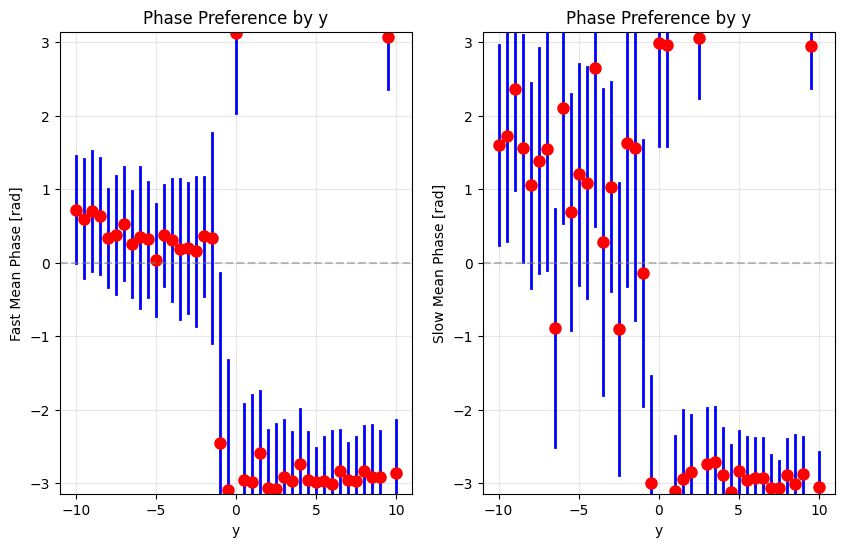

In [4]:

# 创建DataFrame
df_results_fast = pd.DataFrame(results_summary_fast)
df_results_slow = pd.DataFrame(results_summary_slow)

fig, ax = plt.subplots(1,2, figsize=(10, 6))

plt.subplot(1,2,1)
# 绘制竖线图
for _, row in df_results_fast.iterrows():
    plt.plot([row['param'], row['param']], 
             [row['mean'] - row['std'], row['mean'] + row['std']], 
             'b-', linewidth=2)
    plt.plot(row['param'], row['mean'], 'ro', markersize=8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('y')
plt.ylabel('Fast Mean Phase [rad]')
plt.title('Phase Preference by y')
plt.grid(True, alpha=0.3)
plt.ylim(-np.pi, np.pi)

plt.subplot(1,2,2)
# 绘制竖线图
for _, row in df_results_slow.iterrows():
    plt.plot([row['param'], row['param']], 
             [row['mean'] - row['std'], row['mean'] + row['std']], 
             'b-', linewidth=2)
    plt.plot(row['param'], row['mean'], 'ro', markersize=8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('y')
plt.ylabel('Slow Mean Phase [rad]')
plt.title('Phase Preference by y')
plt.grid(True, alpha=0.3)
plt.ylim(-np.pi, np.pi)
plt.show()
